In [1]:
import pandas as pd

In [3]:
import numpy as np

In [5]:
import matplotlib.pyplot as plt

In [7]:
import seaborn as sns

In [9]:
url = 'https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv'

In [11]:
df = pd.read_csv(url)

In [13]:
df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [15]:
df.shape

(506, 14)

In [17]:
df.columns

Index(['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax',
       'ptratio', 'b', 'lstat', 'medv'],
      dtype='object')

In [19]:
X = df.drop('medv', axis=1)

In [21]:
y = df['medv']

In [23]:
from sklearn.model_selection import train_test_split

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [27]:
from sklearn.linear_model import LinearRegression

In [29]:
model = LinearRegression()

In [31]:
model.fit(X_train, y_train)

LinearRegression()

In [33]:
y_pred = model.predict(X_test)

In [35]:
comparison = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})

In [37]:
comparison.head(10)

,Actual,Predicted
0,23.6,28.996724
1,32.4,36.025565
2,13.6,14.816944
3,22.8,25.031979
4,16.1,18.769880
5,20.0,23.254429
6,17.8,17.662538
7,14.0,14.341190
8,19.6,23.013207
9,16.8,20.632456


In [39]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [41]:
mae = mean_absolute_error(y_test, y_pred)

In [43]:
print('MAE :', mae)

MAE : 3.189091965887852


In [45]:
mse = mean_squared_error(y_test, y_pred)

In [47]:
print('MSE :', mse)

MSE : 24.291119474973613


In [49]:
rmse = np.sqrt(mse)

In [51]:
print('RMSE :', rmse)

RMSE : 4.928602182665346


In [53]:
r2 = r2_score(y_test, y_pred)

In [55]:
print('R2 Score :', r2)

R2 Score : 0.6687594935356307


In [57]:
model.coef_

array([-1.13055924e-01,  3.01104641e-02,  4.03807204e-02,  2.78443820e+00,
       -1.72026334e+01,  4.43883520e+00, -6.29636221e-03, -1.44786537e+00,
        2.62429736e-01, -1.06467863e-02, -9.15456240e-01,  1.23513347e-02,
       -5.08571424e-01])

In [59]:
X.columns

Index(['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax',
       'ptratio', 'b', 'lstat'],
      dtype='object')

In [61]:
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

In [63]:
coef_df

,Feature,Coefficient
0,crim,-0.113056
1,zn,0.030110
2,indus,0.040381
3,chas,2.784438
4,nox,-17.202633
5,rm,4.438835
6,age,-0.006296
7,dis,-1.447865
8,rad,0.262430
9,tax,-0.010647


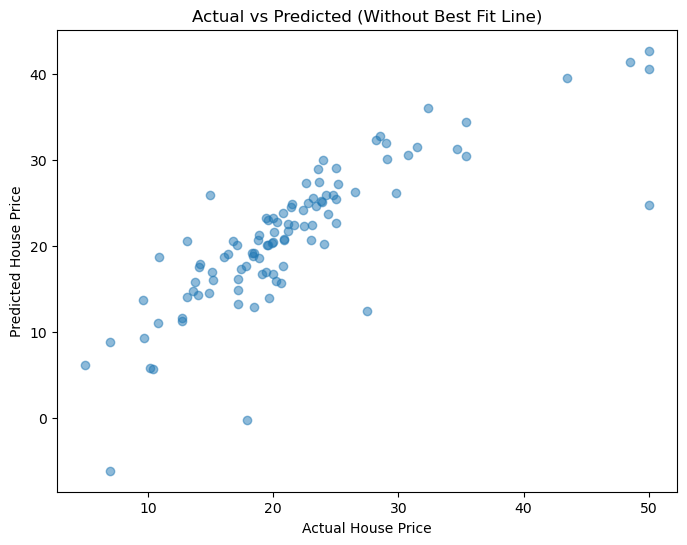

In [65]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.5)

plt.xlabel('Actual House Price')
plt.ylabel('Predicted House Price')
plt.title('Actual vs Predicted (Without Best Fit Line)')

plt.show()

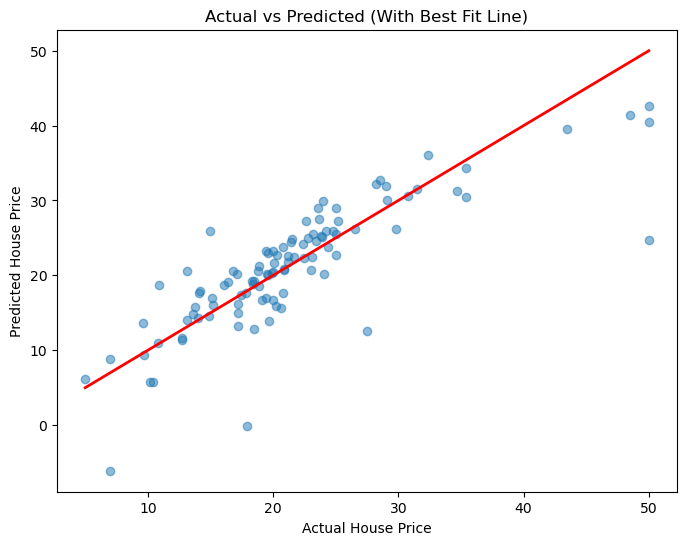

In [67]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.5)

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red',
         linewidth=2)

plt.xlabel('Actual House Price')
plt.ylabel('Predicted House Price')
plt.title('Actual vs Predicted (With Best Fit Line)')

plt.show()

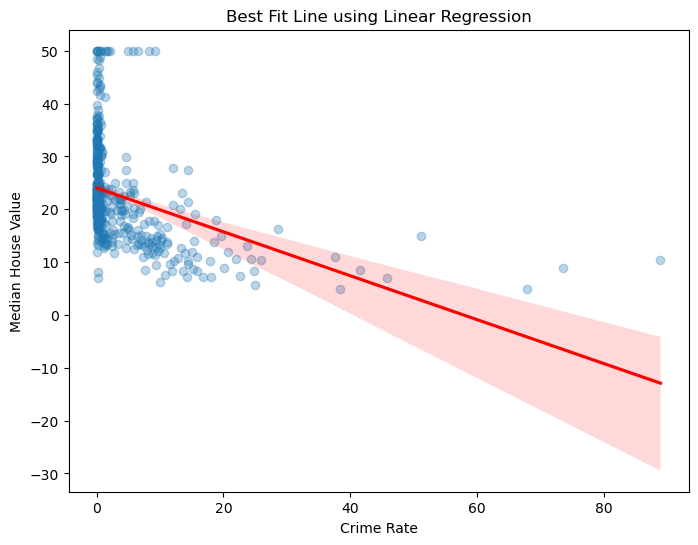

In [69]:
plt.figure(figsize=(8,6))

sns.regplot(
    x='crim',
    y='medv',
    data=df,
    scatter_kws={'alpha':0.3},
    line_kws={'color':'red'}
)

plt.xlabel('Crime Rate')
plt.ylabel('Median House Value')
plt.title('Best Fit Line using Linear Regression')

plt.show()

In [71]:
residuals = y_test - y_pred

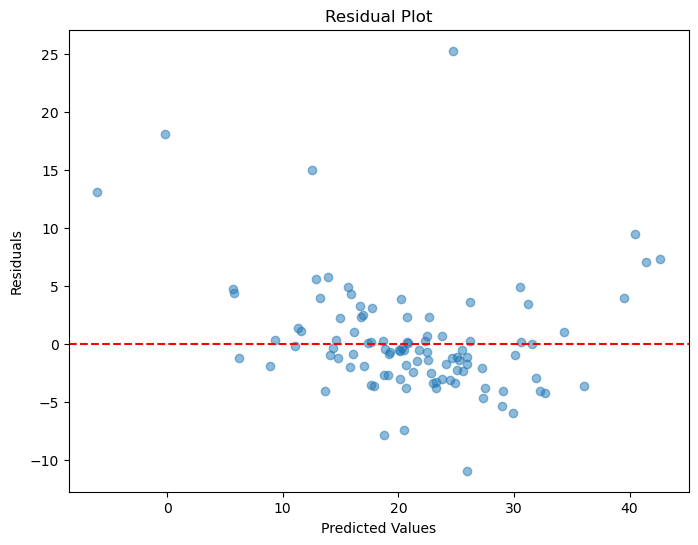

In [73]:
plt.figure(figsize=(8,6))

plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--')

plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')

plt.show()

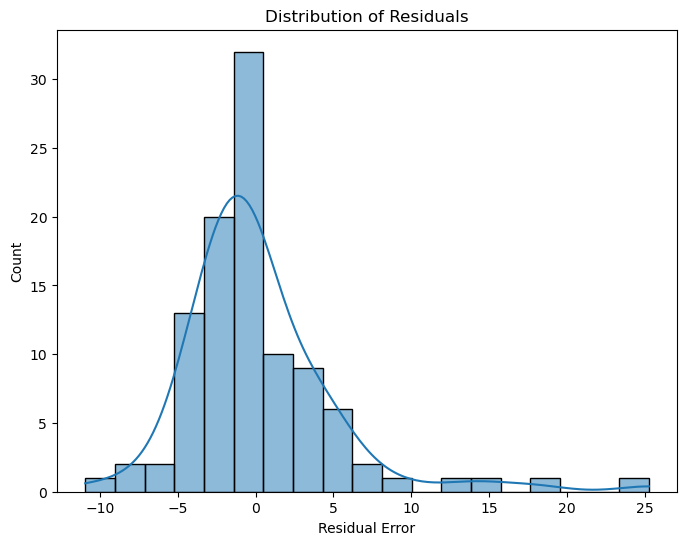

In [75]:
plt.figure(figsize=(8,6))

sns.histplot(residuals, kde=True)

plt.xlabel('Residual Error')
plt.title('Distribution of Residuals')

plt.show()

In [77]:
sample = X_test.iloc[0:1]

In [79]:
sample

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat
173,0.09178,0.0,4.05,0,0.51,6.416,84.1,2.6463,5,296,16.6,395.5,9.04


In [81]:
model.predict(sample)

array([28.99672362])

In [83]:
print('Linear Regression model developed successfully using the Boston Housing Dataset.')

print('MAE  :', round(mae, 4))
print('MSE  :', round(mse, 4))
print('RMSE :', round(rmse, 4))
print('R2   :', round(r2, 4))

Linear Regression model developed successfully using the Boston Housing Dataset.
MAE  : 3.1891
MSE  : 24.2911
RMSE : 4.9286
R2   : 0.6688
